<a href="https://colab.research.google.com/github/Ali-datasmith/data-science-foundations/blob/main/streamlit/streamlit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

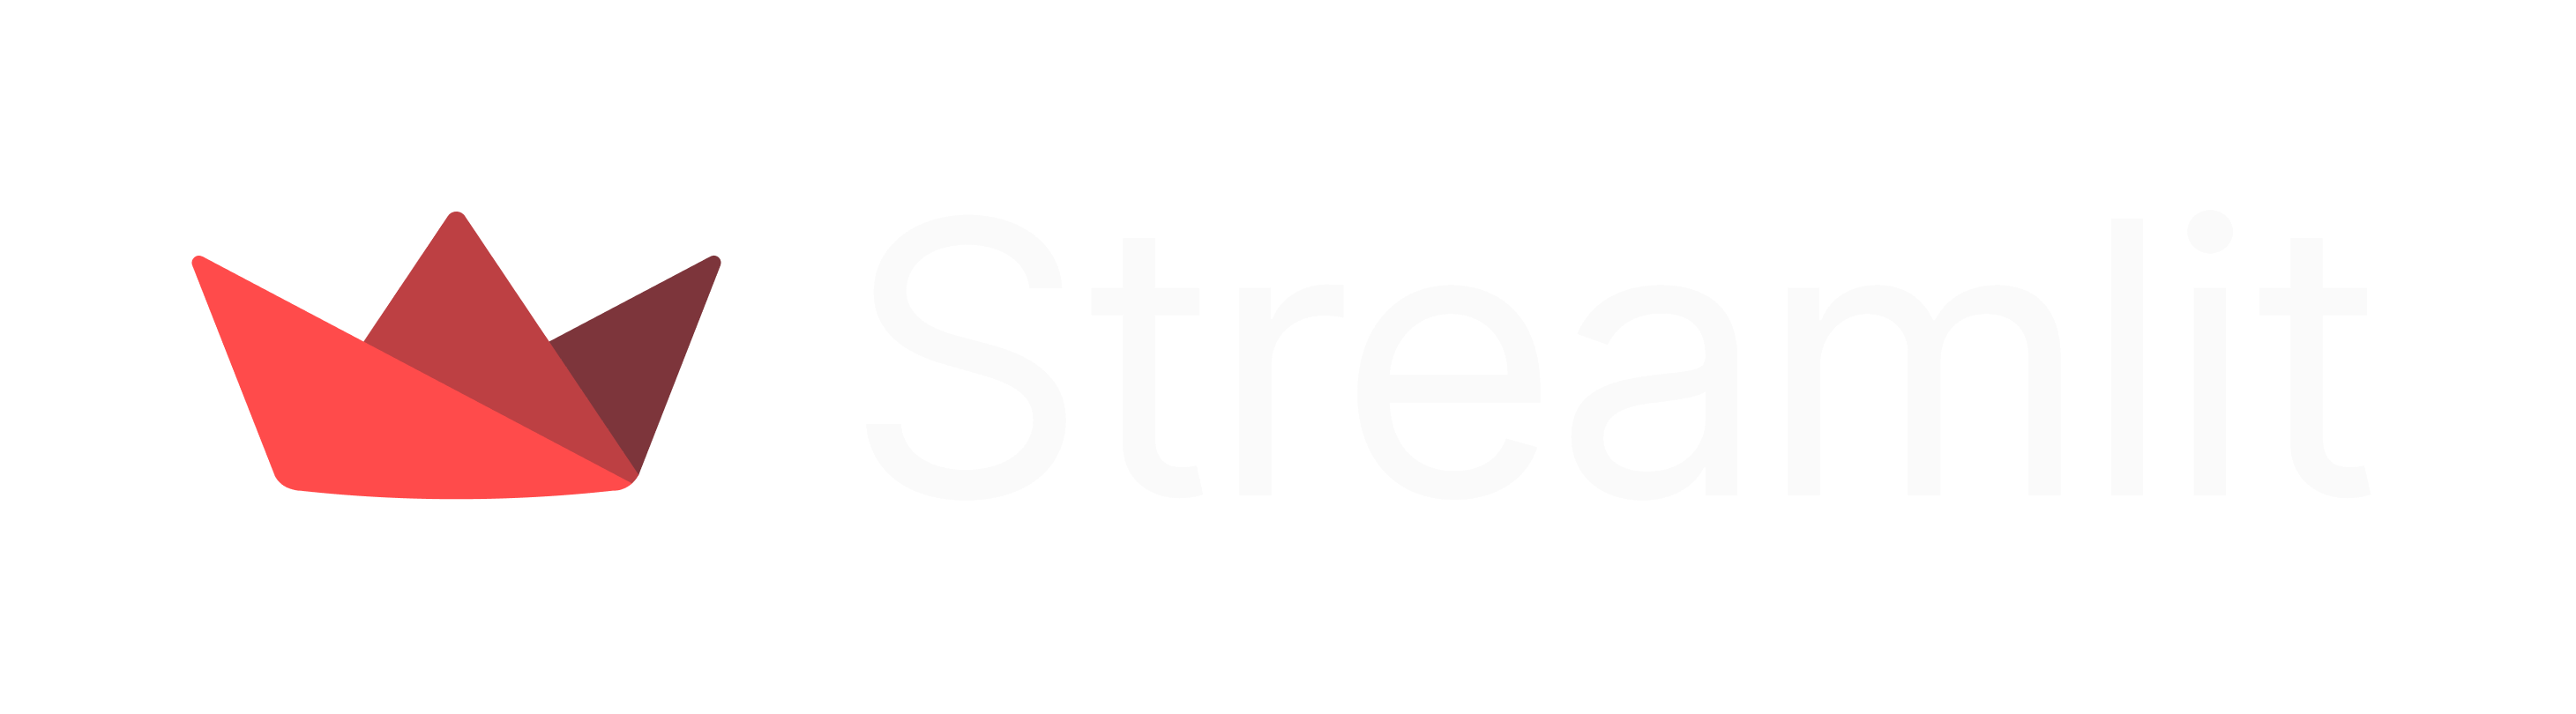

# 🚀 Streamlit Basics — Milestone 1 Reference Notebook

**Author:** Muhammad Ali Rajput
**Last Updated:** April 2026
**Tools:** Streamlit | Polars | Plotly

---

This notebook documents the fundamental building blocks of Streamlit apps. These 5 tools are the foundation for building any interactive data dashboard.

---

## 📚 Table of Contents

| # | Tool | One-Line Explanation |
|---|------|----------------------|
| 1 | `st.title` | Sets the main, large-text heading at the top. |
| 2 | `st.write` | A "Swiss Army knife" to display text or data. |
| 3 | `st.sidebar` | Puts widgets (filters) on the left-hand panel. |
| 4 | `st.selectbox` | A dropdown menu for user selection and filtering. |
| 5 | `st.dataframe` | Displays data in an interactive, searchable table. |
| 6 | `st.plotly_chart` | Renders interactive graphs for data storytelling. |

---

## 🛠️ Phase 1 Essentials (Lessons 1-3)

### 1. Header & Text Display
* **`st.title()`**: The first thing a user sees. It defines the app's purpose.
* **`st.write()`**: The most flexible tool. Use it to explain your analysis or show small data snippets.

### 2. User Controls & Filters
* **`st.sidebar`**: Essential for professional UI. It keeps the main area clean by hiding filters on the left.
* **`st.selectbox()`**: Captures user input. When combined with Polars, it allows the user to slice the data live.

### 3. Data & Visuals
* **`st.dataframe()`**: Unlike a static table, this allows the user to explore the dataset (sort/filter/scroll).
* **`st.plotly_chart()`**: The final output. It turns raw numbers into interactive bars, pies, or scatter plots.

---

## 💡 Professional Tip
A professional app starts with a **Title**, uses the **Sidebar** for a **Selectbox**, processes data via **Polars**, and finally displays the result using **Plotly_chart**. This is the standard pipeline for a data app.

In [1]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 55.0 MB/s eta 0:00:00


### `st.title()` , `st.write()` and `st.dataframe()`
- Sets the main, large-text heading at the top of your application.
- A "Swiss Army knife" function that displays text, dataframes, or charts depending on what you pass to it.
- Displays an interactive, searchable, and sortable table of your data (like a mini-Excel sheet) inside the app.

In [2]:
%%writefile app.py
import streamlit as st
import polars as pl

# 1. Setup the title
st.title("My First Streamlit App")

# 2. The Data (from your specific dataset)
df = pl.DataFrame({
    "product": ["Laptop", "Mouse", "Monitor", "Keyboard", "Headset"],
    "category": ["Electronics", "Accessories", "Electronics", "Accessories", "Electronics"],
    "price": [1200, 25, 300, 45, 85],
    "units_sold": [10, 50, 20, 30, 15]
})

# 3. Displaying text
st.write("Below is the product inventory data loaded via Polars:")

# 4. Displaying the dataframe
st.dataframe(df)

Writing app.py


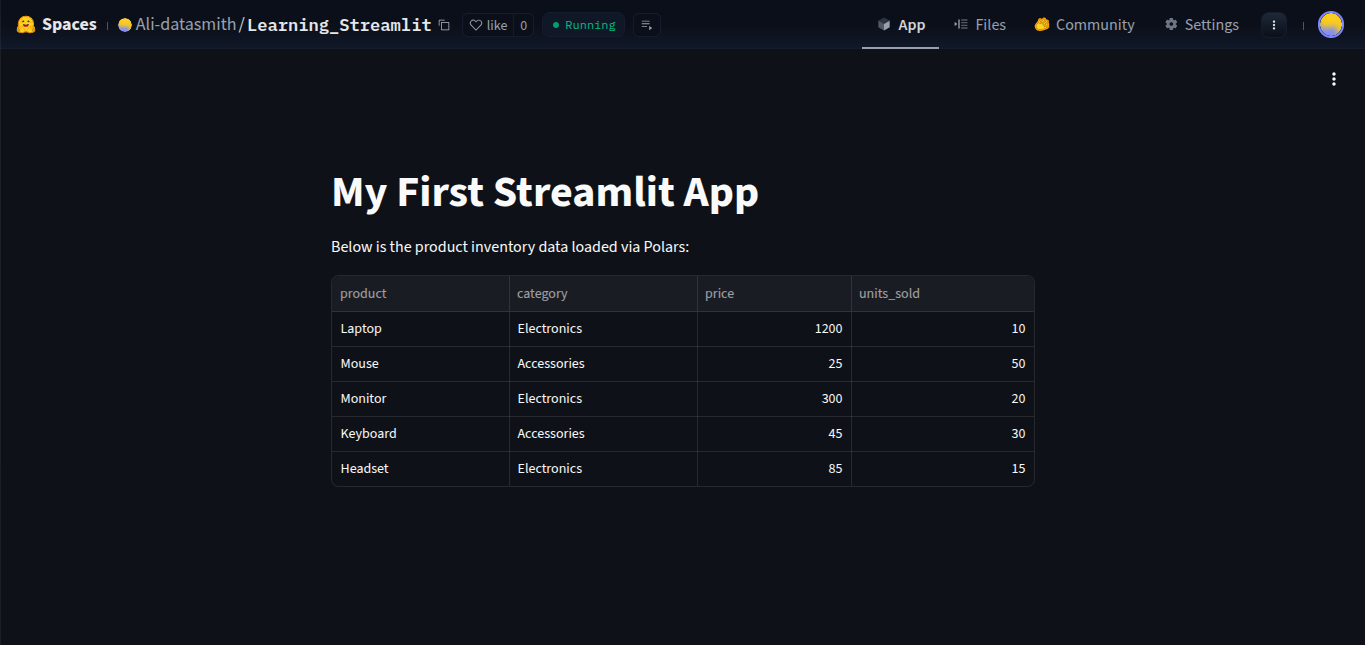

In [ ]:
%%writefile app.py
import streamlit as st
import polars as pl

# 1. Setup the title
st.title("Sales Record")

# 2. The Data (from your specific dataset)
df = pl.DataFrame({
    "product": ["Laptop", "Mouse", "Monitor", "Keyboard", "Headset"],
    "category": ["Electronics", "Accessories", "Electronics", "Accessories", "Electronics"],
    "price": [1200, 25, 300, 45, 85],
    "units_sold": [10, 50, 20, 30, 15]
})

# 3. Displaying text
st.write("Total Products : 5")

# 4. Displaying the dataframe
st.dataframe(df)

Overwriting app.py


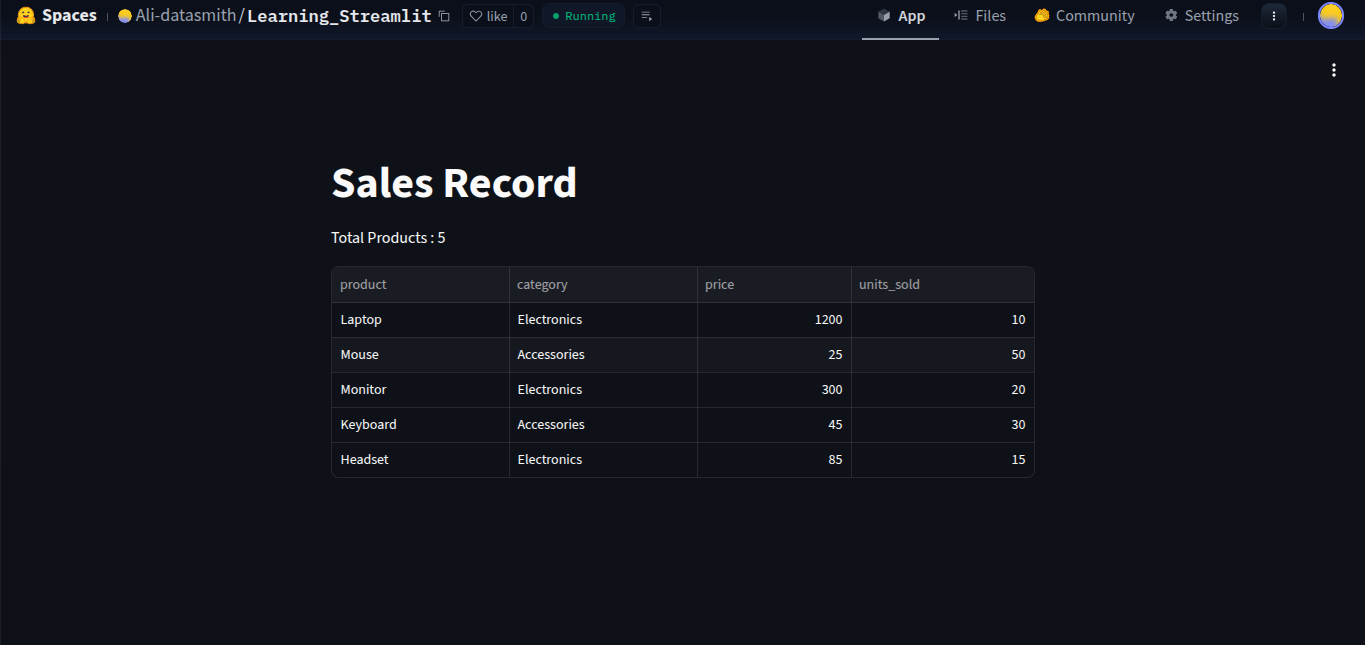

###`st.sidebar.title()` and `st.sidebar.selectbox()`
- A container used to place widgets (like filters or navigation) on the left side of the screen.

In [ ]:
%%writefile app.py
import streamlit as st
import polars as pl

st.title("Product Filter App")

# The Data
df = pl.DataFrame({
    "product": ["Laptop", "Mouse", "Monitor", "Keyboard", "Headset"],
    "category": ["Electronics", "Accessories", "Electronics", "Accessories", "Electronics"],
    "price": [1200, 25, 300, 45, 85],
    "units_sold": [10, 50, 20, 30, 15]
})

# 1. Add a title to the sidebar
st.sidebar.title("Filters")

# 2. Create a dropdown in the sidebar
# We get unique categories from the Polars DF
categories = df["category"].unique().to_list()
selected_cat = st.sidebar.selectbox("Select a Category:", categories)

# 3. Filter the Polars DataFrame based on the selection
filtered_df = df.filter(pl.col("category") == selected_cat)

# 4. Show the results
st.write(f"Showing products for: **{selected_cat}**")
st.dataframe(filtered_df)

Overwriting app.py


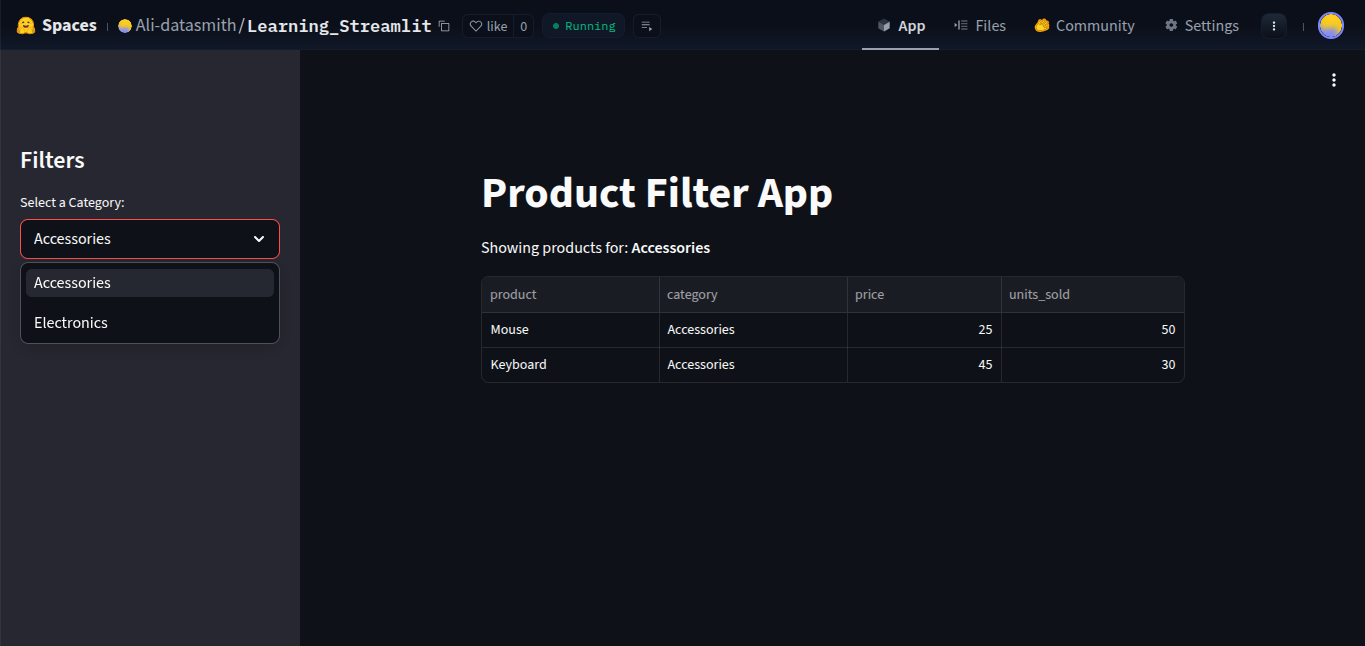

In [ ]:
%%writefile app.py
import streamlit as st
import polars as pl
st.title("Product Filter App By Name")

# The Data
df = pl.DataFrame({
    "product": ["Laptop", "Mouse", "Monitor", "Keyboard", "Headset"],
    "category": ["Electronics", "Accessories", "Electronics", "Accessories", "Electronics"],
    "price": [1200, 25, 300, 45, 85],
    "units_sold": [10, 50, 20, 30, 15]
})

# 1. Add a title to the sidebar
st.sidebar.title("Filters")

# 2. Create a dropdown in the sidebar
# We get unique categories from the Polars DF
product = df['product'].unique().to_list()
selected_product = st.sidebar.selectbox('Select a product : ',product)
# 3. Filter the Polars DataFrame based on the selection
filtered_df = df.filter(pl.col("product") == selected_product)

# 4. Show the results
st.write(f"Displaying **{selected_product}** : ")
st.dataframe(filtered_df)


Overwriting app.py


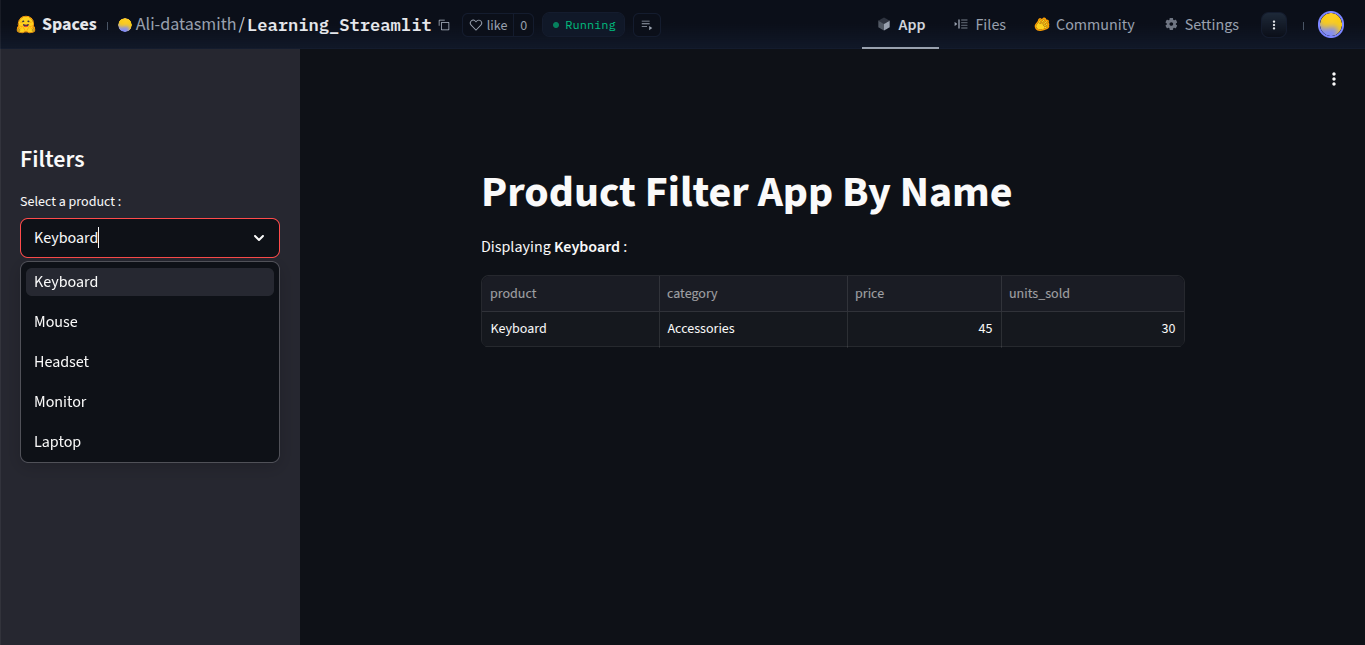

###`st.plotly_chart`
- Renders interactive, high-quality graphs created with the Plotly library directly in your app.

In [ ]:
%%writefile app.py
import streamlit as st
import polars as pl
import plotly.express as px

st.title("Sales Visualization with Plotly")

# The Data
df = pl.DataFrame({
    "product": ["Laptop", "Mouse", "Monitor", "Keyboard", "Headset"],
    "category": ["Electronics", "Accessories", "Electronics", "Accessories", "Electronics"],
    "price": [1200, 25, 300, 45, 85],
    "units_sold": [10, 50, 20, 30, 15]
})

# 1. Create a Sidebar Filter (Combining Lesson 2)
categories = df["category"].unique().to_list()
selected_cat = st.sidebar.selectbox("Select Category", categories)

# 2. Filter the Data
filtered_df = df.filter(pl.col("category") == selected_cat)

# 3. Create a Plotly Figure using the filtered data
fig = px.bar(
    filtered_df,
    x="product",
    y="units_sold",
    title=f"Units Sold: {selected_cat}",
    color="product"
)

# 4. Display the chart
st.plotly_chart(fig)

# 5. Show the raw numbers for reference
st.dataframe(filtered_df)

Overwriting app.py


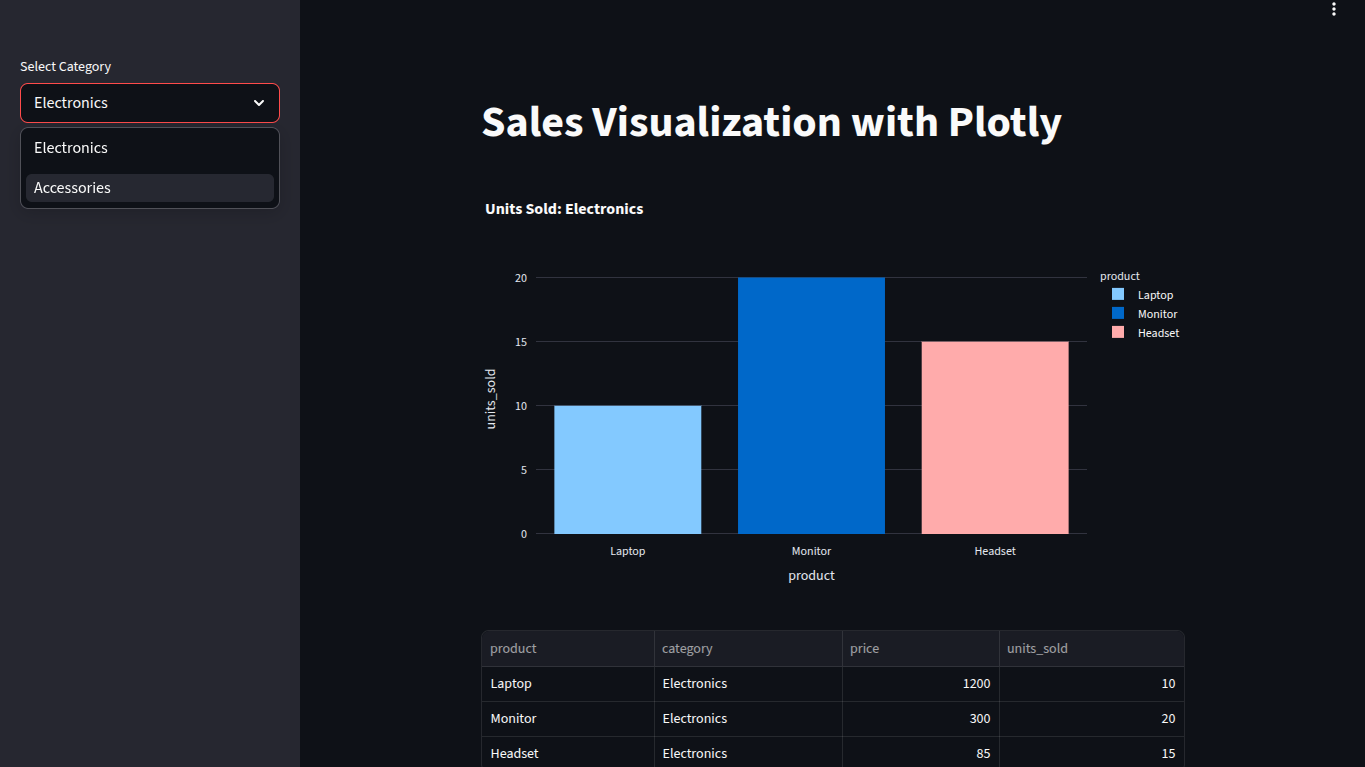

In [ ]:
%%writefile app.py
import streamlit as st
import polars as pl
import plotly.express as px

st.title("Sales Visualization with Plotly")

# The Data
df = pl.DataFrame({
    "product": ["Laptop", "Mouse", "Monitor", "Keyboard", "Headset"],
    "category": ["Electronics", "Accessories", "Electronics", "Accessories", "Electronics"],
    "price": [1200, 25, 300, 45, 85],
    "units_sold": [10, 50, 20, 30, 15]
})

# 1. Sidebar Filter
categories = ["All"] + df["category"].unique().to_list()
selected_cat = st.sidebar.selectbox("Select Category", categories)

# 2. Filter the Data
if selected_cat == "All":
    filtered_df = df
else:
    filtered_df = df.filter(pl.col("category") == selected_cat)

# 3. Create a Plotly Figure
fig = px.scatter(
    filtered_df.to_pandas(),  # Plotly works better with pandas
    x="price",
    y="units_sold",
    color="product",
    size="units_sold",
    template="plotly_dark",
    title='Price VS Units_Sold'
)

# 4. Display the chart
st.plotly_chart(fig)

# 5. Show the raw numbers
st.dataframe(filtered_df)


Overwriting app.py


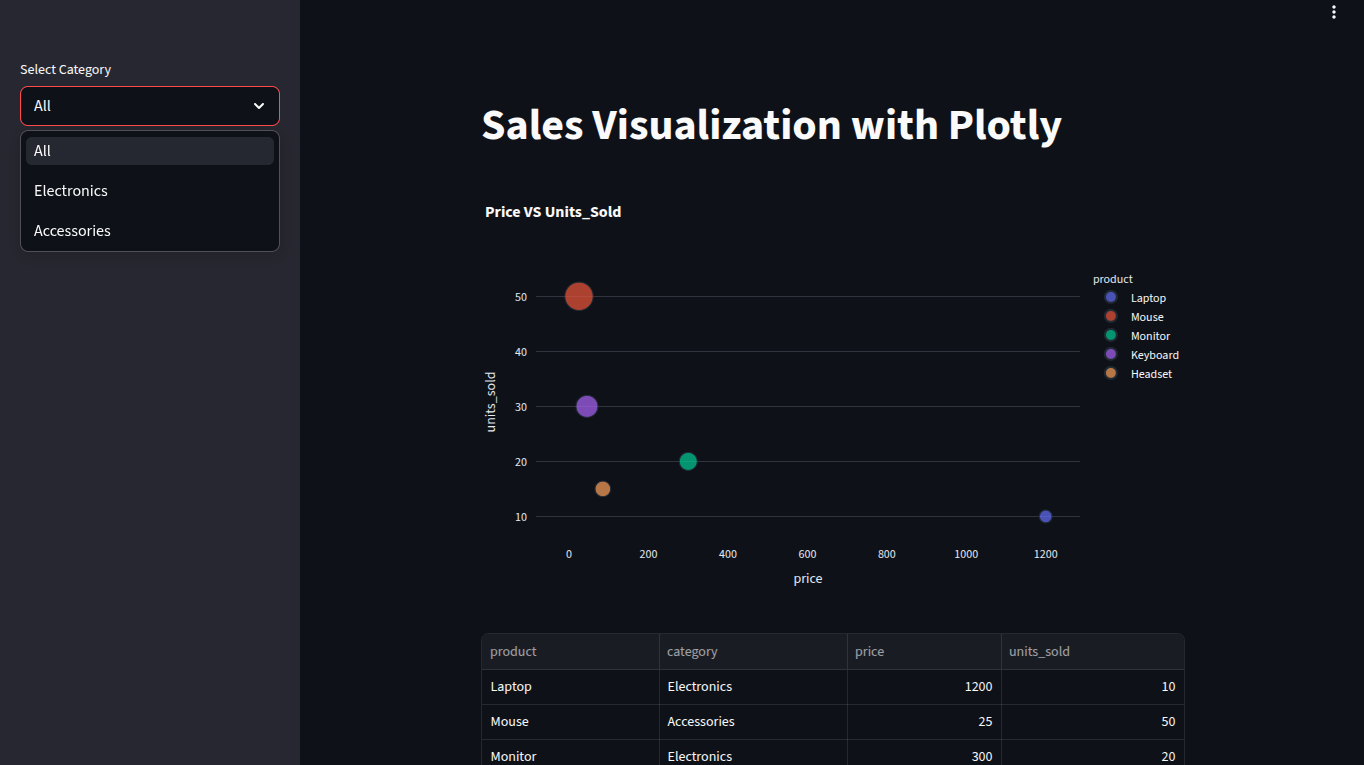

---

## ✅ What We Covered (Streamlit Lessons 1-3)

| Chapter | Topic | Key Methods |
|---------|-------|-------------|
| 1 | **UI Foundation** | `st.title()`, `st.write()` |
| 2 | **Layout & Navigation** | `st.sidebar` |
| 3 | **Interactive Widgets** | `st.selectbox()` |
| 4 | **Data Display** | `st.dataframe()` |
| 5 | **Graph Rendering** | `st.plotly_chart()` |

---

## 🔑 Key Takeaways

- **`st.title` & `st.write`** — The essential tools for app branding and displaying dynamic text or objects.
- **`st.sidebar` for Professionalism** — Keeps the dashboard clean by moving interactive controls to the left panel.
- **`st.selectbox` for Live Filtering** — Captures user input to drive real-time data updates across the app.
- **`st.dataframe` for Exploration** — Provides an interactive UI for Polars DataFrames with built-in sorting and searching.
- **`st.plotly_chart` Integration** — Seamlessly displays interactive Plotly visualizations within the Streamlit grid.
- **Instant Feedback Loop** — Every widget interaction triggers an automatic script re-run to reflect changes instantly.

---

## 🔵 End of Streamlit Section (Lessons 1-3)

This notebook documents the fundamental Streamlit toolkit used to transform static analysis into an interactive web experience.

*Next: Advanced Dashboard Layouts and Cloud Data Integration.*